In [9]:
library(Signac)
library(Seurat)
library(EnsDb.Mmusculus.v79)
library(BSgenome.Mmusculus.UCSC.mm10)
library(dplyr)
library(ggplot2)
library(data.table)
library(rtracklayer)
library(stringr)
library(cowplot)
# 加载必要的库
library(tidyr)
library(ggpubr)

library(scran)
library(scater)
library(cluster)
library(parallelDist)
library(ggtext)
library(bluster)

In [ ]:
combined是seurat对象，activity记录了每一个TF对应的调节子在每一个细胞中的活性（0或者1二值化，第一列X是细胞cell_id，第二列是cellclass,后面每一列是TF名称），AUC_gene是调节子活性矩阵，第一列Cell是细胞cell_id，后面每一列是一个调节子（例如Ahctf1_direct_..._.39g.[R语言读入无法识别“+/+”为列名]），现在我想比较每种细胞类型中AD和WT差异的GRN（Mann–Whitney U），且限制调节子激活比例不低于10%，combined的meta.data中记录了每一个cell_id对应的genotype(AD WT),月龄（month）和细胞类型(class_id_label),帮我写出差异分析的完整代码

In [2]:
combined=readRDS('/public/home/yzhang/zy_data/Project_AD_st/Multiome/Raw_data_0423_full/QC_0512/Combine/Combine_RNA_ATAC_anno_rnafromatac_260219.rds')

In [ ]:
# 激活比例filter wilcox  
two-sided Mann–Whitney U + BH-FDR （3篇）
ANOVA + Bonferroni （20年 NCB）
earlyDETest (轨迹差异分析方法 24 Nature)

In [34]:
activity=read.csv('/home1/yzhang/Project_SN_Multiome/Analysis/Scenic+/Version_2_mouse/binarize/b_matrix(1).csv')

In [35]:
head(activity) # 只有+/+

,X,cellclass,Ahctf1,Ar,Arntl,Atf6,Bach2,Cebpa,Chd2,Ctnnb1,⋯,Tcf4,Tcf7l2,Tef,Thra,Thrb,Zbtb16,Zeb1,Zfp148,Zfp57,Zfp740
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,CTCTCGATACAGTCGAC-HZ6U_pal,01 IT-ET Glut,0,1,0,1,0,0,0,0,⋯,1,0,0,1,1,1,1,1,0,0
2,TTTGTTGGCTAGGTCAG-WT3U_sub,08 CNU-MGE GABA,1,1,0,1,1,0,0,0,⋯,1,0,0,1,1,1,1,1,1,0
3,GGAATCTTACGGTCGGT-HZ3U_pal,07 CTX-MGE GABA,0,1,0,1,1,0,0,0,⋯,1,0,0,1,1,0,1,1,1,0
4,TGTTTGTGCTACAGTCT-HZ2U_sub,09 CNU-LGE GABA,0,1,0,1,0,0,0,0,⋯,1,0,0,1,1,0,1,1,1,0
5,ACAACCATACCCGATCC-HZ2U_pal,34 Immune,1,0,0,0,0,1,1,0,⋯,0,0,0,0,0,0,0,0,1,0
6,AGTCTCCGCTGGCTGAA-HZ3U_sub,01 IT-ET Glut,0,1,0,1,0,0,0,0,⋯,1,0,0,1,1,1,1,1,1,0


In [36]:
library(dplyr)

# 1. 读入数据，强制 R 语言保留原始列名（不将特殊符号变成点号）
AUC_gene <- read.csv('/home1/yzhang/Project_SN_Multiome/Analysis/Scenic+/Version_2_mouse/gene_AUC_matrix.csv', check.names = FALSE)

# 2. 识别并过滤列
# 第一列通常是细胞ID，我们先把它单独拿出来（假设列名叫 "Cell" 或 第一列）
cell_col_name <- colnames(AUC_gene)[1]

# 获取所有列名
all_cols <- colnames(AUC_gene)

# 使用 grep 匹配包含 "+/+" 的列
# 注意：在正则表达式中 "+" 是特殊字符，需要用 "\\+" 进行转义
plus_plus_cols <- all_cols[grepl("\\+/\\+", all_cols)]

# 将 细胞ID列 和 带有 "+/+" 的列合并，完成过滤
AUC_gene <- AUC_gene[, c(cell_col_name, plus_plus_cols)]

# 3. 检查过滤后的列名是否正确
print(paste("过滤后剩余列数:", ncol(AUC_gene)))
head(colnames(AUC_gene))

[1] "过滤后剩余列数: 104"


[1] "Cell"                    "Ahctf1_direct_+/+_(39g)"
[3] "Ar_direct_+/+_(179g)"    "Arntl_direct_+/+_(37g)" 
[5] "Atf6_direct_+/+_(86g)"   "Bach2_direct_+/+_(89g)"

In [37]:
head(AUC_gene)

,Cell,Ahctf1_direct_+/+_(39g),Ar_direct_+/+_(179g),Arntl_direct_+/+_(37g),Atf6_direct_+/+_(86g),Bach2_direct_+/+_(89g),Cebpa_direct_+/+_(24g),Chd2_direct_+/+_(388g),Ctnnb1_direct_+/+_(54g),Cux2_direct_+/+_(17g),⋯,Tcf4_direct_+/+_(991g),Tcf7l2_direct_+/+_(175g),Tef_direct_+/+_(140g),Thra_direct_+/+_(285g),Thrb_direct_+/+_(566g),Zbtb16_direct_+/+_(32g),Zeb1_direct_+/+_(402g),Zfp148_direct_+/+_(856g),Zfp57_direct_+/+_(15g),Zfp740_direct_+/+_(22g)
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,CTCTCGATACAGTCGAC-HZ6U_pal,0.02159739,0.15475816,0.10731514,0.1986553,0.04624873,0.00000000,0.02796927,0.01537173,0.05832015,⋯,0.11229550,0.04823612,0.07757597,0.08744477,0.15379016,0.206945293,0.07734859,0.11355340,0.00000000,0.02083796
2,TTTGTTGGCTAGGTCAG-WT3U_sub,0.03642405,0.10081818,0.11828454,0.2022517,0.14200159,0.00000000,0.03449134,0.01566603,0.10779520,⋯,0.13992312,0.04656654,0.05601642,0.10459400,0.15507745,0.176382946,0.10874418,0.11377619,0.02901385,0.02467215
3,GGAATCTTACGGTCGGT-HZ3U_pal,0.03413579,0.11714770,0.12664376,0.1946182,0.13746875,0.01747148,0.05163461,0.01713755,0.15173306,⋯,0.13398336,0.04923507,0.08526022,0.11565221,0.17861370,0.163852384,0.10536559,0.11416465,0.09828851,0.05395643
4,TGTTTGTGCTACAGTCT-HZ2U_sub,0.01608050,0.13009657,0.15023459,0.2800222,0.04249883,0.00000000,0.05090994,0.02252558,0.16165684,⋯,0.07078499,0.03414600,0.15911631,0.10329859,0.12798820,0.037706296,0.13514944,0.09883349,0.03545232,0.05401200
5,ACAACCATACCCGATCC-HZ2U_pal,0.03880634,0.02315226,0.05788674,0.0708620,0.01129090,0.18210065,0.06462204,0.05034864,0.07011362,⋯,0.03046489,0.04991966,0.02903423,0.03613006,0.04545474,0.003285452,0.06245362,0.06557623,0.01809291,0.03978662
6,AGTCTCCGCTGGCTGAA-HZ3U_sub,0.01253840,0.17417465,0.16596181,0.3530449,0.06014945,0.00000000,0.02896806,0.03850856,0.10189846,⋯,0.14144045,0.04725114,0.12202235,0.15684382,0.20350851,0.235024450,0.10059118,0.14339882,0.04009780,0.06090242


In [17]:
# 加载必要的R包
library(Seurat)
library(dplyr)
library(tidyr)
library(tibble)

In [38]:
# 加载必要的R包
library(Seurat)
library(dplyr)

# 1. 数据准备与对齐 ========================================

# 从 Seurat 对象中提取 metadata
meta <- combined@meta.data
meta$cell_id <- rownames(meta)

# --- 新增：修复细胞ID格式的函数 ---
# 目标：将 "CTCTCGATACAGTCGAC-HZ6U_pal" 转换为 "HZ6U_pal_CTCTCGATACAGTCGAC"
fix_cell_ids <- function(ids) {
  # 正则表达式解释：
  # ^([^-]+) : 匹配开头到第一个 "-" 之间的所有字符（即 Barcode），记为组1
  # -        : 匹配中间的 "-"
  # (.*)$    : 匹配 "-" 后面的所有字符（即 Sample），记为组2
  # \\2_\\1  : 替换为 "组2_组1"
  gsub("^([^-]+)-(.*)$", "\\2_\\1", ids)
}

# 转换 activity 和 AUC_gene 的细胞 ID
activity$X <- fix_cell_ids(activity$X)
AUC_gene[[cell_col_name]] <- fix_cell_ids(AUC_gene[[cell_col_name]])

# 将转换后的 ID 设置为行名
rownames(activity) <- activity$X
rownames(AUC_gene) <- AUC_gene[[cell_col_name]]

# 检查转换是否成功
print("检查转换后的 activity 行名:")
print(head(rownames(activity), 3))
print("检查 combined 的 cell_id:")
print(head(meta$cell_id, 3))

# 寻找三个数据集中共有的细胞ID
common_cells <- intersect(intersect(meta$cell_id, rownames(activity)), rownames(AUC_gene))
print(paste("---- 成功对齐！共有细胞数:", length(common_cells), "----"))

# 提取交集数据
meta <- meta[common_cells, ]
activity <- activity[common_cells, ]
AUC_gene <- AUC_gene[common_cells, ]

[1] "检查转换后的 activity 行名:"
[1] "HZ6U_pal_CTCTCGATACAGTCGAC" "WT3U_sub_TTTGTTGGCTAGGTCAG"
[3] "HZ3U_pal_GGAATCTTACGGTCGGT"
[1] "检查 combined 的 cell_id:"
[1] "HZ1U_pal_AAACCCAATGAGAGTTC" "HZ1U_pal_AAACCCACGAGTTGCGC"
[3] "HZ1U_pal_AAACCCAGCTCGGCACT"
[1] "---- 成功对齐！共有细胞数: 131083 ----"


In [45]:
meta

,X,orig.ident,genotype,month,batch,isDbl_scDblFinder,brain,celltype_base_marker,cell_id,iter_cluster,⋯,nucleosome_signal,nucleosome_percentile,TSS.enrichment,TSS.percentile,blacklist_fraction,nt_type_label,class_id_label,neighborhood,nCount_RNA_from_ATAC,nFeature_RNA_from_ATAC
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>
HZ1U_pal_AAACCCAATGAGAGTTC,HZ1U_pal_AAACCCAATGAGAGTTC,HZ1U_pal,AD,1,423,1,pal,Micro,HZ1U_pal_AAACCCAATGAGAGTTC,1_0_0,⋯,0.4250310,0.14,8.680974,0.73,0.02966772,NA,34 Immune,NN-IMN-GC,3009,2338
HZ1U_pal_AAACCCACGAGTTGCGC,HZ1U_pal_AAACCCACGAGTTGCGC,HZ1U_pal,AD,1,423,1,pal,InN,HZ1U_pal_AAACCCACGAGTTGCGC,15_0_0_0,⋯,0.4996466,0.46,4.348955,0.21,0.02429374,GABA,06 CTX-CGE GABA,Subpallium-GABA,12834,6427
HZ1U_pal_AAACCCAGCTCGGCACT,HZ1U_pal_AAACCCAGCTCGGCACT,HZ1U_pal,AD,1,423,1,pal,ExN,HZ1U_pal_AAACCCAGCTCGGCACT,14_3_0_0,⋯,0.4883136,0.40,4.343122,0.21,0.02758488,Glut,01 IT-ET Glut,Pallium-Glut,12618,6254
HZ1U_pal_AAACCCATACCAGCCCT,HZ1U_pal_AAACCCATACCAGCCCT,HZ1U_pal,AD,1,423,1,pal,ExN,HZ1U_pal_AAACCCATACCAGCCCT,1_1_0_0,⋯,0.5262609,0.61,5.440461,0.31,0.02393981,Glut,01 IT-ET Glut,Pallium-Glut,9674,5376
HZ1U_pal_AAACCCATACTCCCATG,HZ1U_pal_AAACCCATACTCCCATG,HZ1U_pal,AD,1,423,1,pal,InN,HZ1U_pal_AAACCCATACTCCCATG,0_0_1_0,⋯,0.4622951,0.29,8.678278,0.73,0.02713944,GABA,09 CNU-LGE GABA,Subpallium-GABA,5268,3828
HZ1U_pal_AAACGAACGAACTCCAA,HZ1U_pal_AAACGAACGAACTCCAA,HZ1U_pal,AD,1,423,1,pal,ExN,HZ1U_pal_AAACGAACGAACTCCAA,4_0_3_0,⋯,0.4984252,0.45,4.115183,0.19,0.01669086,Glut,02 NP-CT-L6b Glut,Pallium-Glut,3694,2400
HZ1U_pal_AAACGAACGAAGGACTG,HZ1U_pal_AAACGAACGAAGGACTG,HZ1U_pal,AD,1,423,1,pal,ExN,HZ1U_pal_AAACGAACGAAGGACTG,9_0_1_0,⋯,0.5679389,0.79,7.324255,0.56,0.02300280,Glut,04 DG-IMN Glut,Pallium-Glut; NN-IMN-GC,2056,1731
HZ1U_pal_AAACGAATACCCTAACT,HZ1U_pal_AAACGAATACCCTAACT,HZ1U_pal,AD,1,423,1,pal,ExN,HZ1U_pal_AAACGAATACCCTAACT,1_2_0_0,⋯,0.5600636,0.76,7.069335,0.53,0.02117381,Glut,01 IT-ET Glut,Pallium-Glut,4447,3363
HZ1U_pal_AAACGAATACCGAGTGC,HZ1U_pal_AAACGAATACCGAGTGC,HZ1U_pal,AD,1,423,1,pal,Micro,HZ1U_pal_AAACGAATACCGAGTGC,1_0_1,⋯,0.4153846,0.10,10.732601,0.92,0.03104318,NA,34 Immune,NN-IMN-GC,3645,2852


In [39]:
# 2. 建立 activity(TF) 和 AUC(Regulon) 的名称映射 =================
# 获取 AUC_gene 中所有的调节子列名（排除 'Cell' 列）
auc_cols <- setdiff(colnames(AUC_gene), "Cell")

# 提取TF名称：假设调节子列名第一个 "_" 前面的是 TF 名称 (例如 "Ahctf1" 提取自 "Ahctf1_direct_..._.39g.")
tf_names <- sapply(strsplit(auc_cols, "_"), `[`, 1)

# 创建映射字典
regulon_mapping <- data.frame(
  AUC_name = auc_cols,
  TF_name = tf_names,
  stringsAsFactors = FALSE
)

# 仅保留在 activity 矩阵中也存在的 TF
regulon_mapping <- regulon_mapping %>% filter(TF_name %in% colnames(activity))

In [43]:
regulon_mapping

AUC_name,TF_name
<chr>,<chr>
Ahctf1_direct_+/+_(39g),Ahctf1
Ar_direct_+/+_(179g),Ar
Arntl_direct_+/+_(37g),Arntl
Atf6_direct_+/+_(86g),Atf6
Bach2_direct_+/+_(89g),Bach2
Cebpa_direct_+/+_(24g),Cebpa
Chd2_direct_+/+_(388g),Chd2
Ctnnb1_direct_+/+_(54g),Ctnnb1
Cux2_direct_+/+_(17g),Cux2


In [49]:
# 3. 执行按细胞类型和月龄的差异分析循环 ==================================
cell_types <- unique(meta$class_id_label)
months <- unique(meta$month) # 获取所有月龄
results_list <- list()

for (ct in cell_types) {
  for (m in months) {
    message
    # 提取当前细胞类型且为当前月龄的细胞ID
    cells_ct_m <- meta$cell_id[meta$class_id_label == ct & meta$month == m]
    
    # 如果该子集总细胞数太少（如少于20个），则跳过
    if (length(cells_ct_m) < 20) next 
    
    # 提取当前子集的 metadata, activity 和 AUC 矩阵
    meta_ct_m <- meta[cells_ct_m, ]
    act_ct_m <- activity[cells_ct_m, ]
    auc_ct_m <- AUC_gene[cells_ct_m, ]
    
    # 区分 AD 和 WT 的细胞
    cells_AD <- meta_ct_m$cell_id[meta_ct_m$genotype == "AD"]
    cells_WT <- meta_ct_m$cell_id[meta_ct_m$genotype == "WT"]
    
    # 确保两组都有足够的细胞进行统计检验（例如至少3个）
    if (length(cells_AD) < 3 | length(cells_WT) < 3) next
    
    # -- 修改过滤条件：在 AD 或 WT 其中一组中激活比例 >= 10% 即可 --
    
    # 提取对应组别的TF活性矩阵 (使用 drop = FALSE 防止单行变向量导致 colMeans 报错)
    tf_matrix_AD <- act_ct_m[cells_AD, regulon_mapping$TF_name, drop = FALSE]
    tf_matrix_WT <- act_ct_m[cells_WT, regulon_mapping$TF_name, drop = FALSE]
    
    # 分别计算 AD 和 WT 组内每个TF的激活比例 (值为1的比例)
    ratio_AD <- colMeans(tf_matrix_AD == 1, na.rm = TRUE)
    ratio_WT <- colMeans(tf_matrix_WT == 1, na.rm = TRUE)
    
    # 筛选：AD >= 10% 或 WT >= 10%
    valid_idx <- (ratio_AD >= 0.1) | (ratio_WT >= 0.1)
    valid_idx[is.na(valid_idx)] <- FALSE # 处理潜在的 NA
    
    # 提取满足条件的 TF 名称
    valid_tfs <- regulon_mapping$TF_name[valid_idx]
    
    # 如果没有满足条件的TF，跳过当前子集
    if (length(valid_tfs) == 0) next
    
    # 获取满足条件的对应的 AUC_gene 列名
    valid_auc_cols <- regulon_mapping$AUC_name[regulon_mapping$TF_name %in% valid_tfs]
    
    # -- Mann-Whitney U Test (Wilcoxon rank-sum test) --
    # 遍历每一个满足条件的 regulon 进行检验
    res_ct_m <- lapply(valid_auc_cols, function(reg) {
      
      val_AD <- as.numeric(auc_ct_m[cells_AD, reg])
      val_WT <- as.numeric(auc_ct_m[cells_WT, reg])
      
      # 检验 (exact = FALSE 防止因AUC分数存在相同值/ties而报错)
      wt_test <- wilcox.test(val_AD, val_WT, exact = FALSE)
      
      # 计算均值
      mean_AD <- mean(val_AD, na.rm = TRUE)
      mean_WT <- mean(val_WT, na.rm = TRUE)
      
      # 加上伪计数 1e-5 防止 log2(0)
      log2FC <- log2((mean_AD + 1e-5) / (mean_WT + 1e-5))
      
      # 提取映射的 TF 名及两组的独立激活比例
      tf_name <- regulon_mapping$TF_name[regulon_mapping$AUC_name == reg]
      act_AD <- ratio_AD[tf_name]
      act_WT <- ratio_WT[tf_name]
      
      data.frame(
        CellType = ct,
        Month = m,                   # 新增月龄信息
        Regulon = reg,
        TF = tf_name,
        Active_Ratio_AD = act_AD,    # 输出AD组激活比例
        Active_Ratio_WT = act_WT,    # 输出WT组激活比例
        Mean_AD = mean_AD,
        Mean_WT = mean_WT,
        log2FC = log2FC,
        p_val = wt_test$p.value
      )
    })
    
    # 合并当前子集的结果
    res_ct_m_df <- do.call(rbind, res_ct_m)
    
    # 添加多重假设检验校正 (FDR / Benjamini-Hochberg)
    res_ct_m_df$p_val_adj <- p.adjust(res_ct_m_df$p_val, method = "BH")
    
    # 使用 细胞类型_月龄 作为列表的名称
    list_name <- paste(ct, m, sep = "_")
    results_list[[list_name]] <- res_ct_m_df
  }
}

# 4. 汇总最终结果 ==========================================
# 将所有细胞类型和月龄的结果合并为一个大的 data.frame
final_diff_GRN <- do.call(rbind, results_list)
rownames(final_diff_GRN) <- NULL

# 查看结果前几行
head(final_diff_GRN)

# 选出显著上调或下调的调节子 (例如: FDR < 0.05)
significant_GRN <- final_diff_GRN %>% filter(p_val_adj < 0.05)

# 保存结果
# write.csv(final_diff_GRN, "Differential_GRN_AD_vs_WT_by_Month.csv", row.names = FALSE)

,CellType,Month,Regulon,TF,Active_Ratio_AD,Active_Ratio_WT,Mean_AD,Mean_WT,log2FC,p_val,p_val_adj
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,34 Immune,1,Ahctf1_direct_+/+_(39g),Ahctf1,0.2694843,0.2796818,0.024681223,0.02523495,-0.0319963591,3.749255e-01,4.949017e-01
2,34 Immune,1,Cebpa_direct_+/+_(24g),Cebpa,0.9926328,0.9883721,0.208234757,0.19850541,0.0690291978,5.722486e-07,1.573684e-06
3,34 Immune,1,Chd2_direct_+/+_(388g),Chd2,0.2644436,0.2705018,0.054504387,0.05451099,-0.0001748362,9.274442e-01,9.274442e-01
4,34 Immune,1,Cux2_direct_+/+_(17g),Cux2,0.2687088,0.2625459,0.050333188,0.05024050,0.0026585390,8.087761e-01,8.962218e-01
5,34 Immune,1,E2f3_direct_+/+_(25g),E2f3,0.7716169,0.7723378,0.114479371,0.11442734,0.0006557607,8.690636e-01,8.962218e-01
6,34 Immune,1,E2f4_direct_+/+_(10g),E2f4,0.1124467,0.1536108,0.008391171,0.01083546,-0.3684282383,1.467464e-03,3.459023e-03


In [60]:
significant_GRN[grep('Mef2c',significant_GRN$Regulon),]

,CellType,Month,Regulon,TF,Active_Ratio_AD,Active_Ratio_WT,Mean_AD,Mean_WT,log2FC,p_val,p_val_adj
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
81,06 CTX-CGE GABA,6,Mef2c_direct_+/+_(703g),Mef2c,0.91334895,0.9528986,0.09910032,0.10685566,-0.10869116,1.524819e-10,7.624097e-10
151,01 IT-ET Glut,2,Mef2c_direct_+/+_(703g),Mef2c,0.99811980,0.9993014,0.17124379,0.17319891,-0.01637723,9.542926e-03,1.134834e-02
192,01 IT-ET Glut,3,Mef2c_direct_+/+_(703g),Mef2c,0.99905949,0.9990551,0.17690467,0.17505245,0.01518403,8.319865e-03,1.039983e-02
234,01 IT-ET Glut,6,Mef2c_direct_+/+_(703g),Mef2c,0.99939284,0.9997424,0.15786045,0.17058371,-0.11182325,7.870495e-118,4.022698e-117
274,09 CNU-LGE GABA,1,Mef2c_direct_+/+_(703g),Mef2c,0.96571003,0.9628306,0.11298606,0.11144714,0.01978343,6.326204e-03,1.686988e-02
315,09 CNU-LGE GABA,3,Mef2c_direct_+/+_(703g),Mef2c,0.98712596,0.9777117,0.11665239,0.11438299,0.02834095,9.089567e-07,1.436738e-06
362,09 CNU-LGE GABA,6,Mef2c_direct_+/+_(703g),Mef2c,0.92049745,0.9712919,0.10303114,0.11234922,-0.12489815,1.930306e-154,5.576441e-154
417,02 NP-CT-L6b Glut,2,Mef2c_direct_+/+_(703g),Mef2c,0.99237473,0.9940828,0.13662098,0.14176367,-0.05330495,8.770542e-12,8.989806e-11
447,02 NP-CT-L6b Glut,3,Mef2c_direct_+/+_(703g),Mef2c,0.99822538,0.9944853,0.14748040,0.14306914,0.04380767,9.293499e-10,5.443335e-09


In [54]:
dim(significant_GRN)

[1] 1380   11

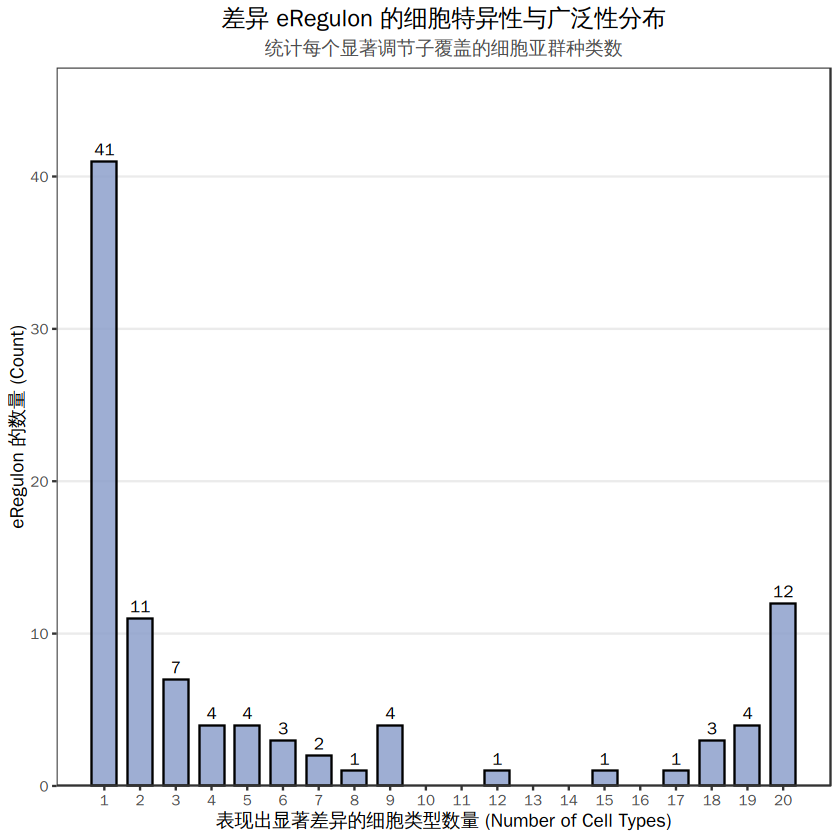

In [59]:
library(dplyr)
library(ggplot2)

# 1. 统计每个 Regulon 在多少个【唯一】的细胞类型中显著
# 注意：即使同一个 Regulon 在某细胞的多个月龄都显著，这里按细胞类型去重只算 1 次
regulon_counts <- significant_GRN %>%
  filter(log2FC<0)%>%
  group_by(Regulon, TF) %>%
  summarise(Num_CellTypes = n_distinct(CellType), .groups = "drop")

# 2. 绘制分布直方图 (Bar chart for discrete counts)
p_regulon_dist <- ggplot(regulon_counts, aes(x = Num_CellTypes)) +
  geom_bar(fill = "#8DA0CB", color = "black", alpha = 0.85, width = 0.7) +
  
  # 在柱子上方添加具体的数字标签
  geom_text(stat = 'count', aes(label = ..count..), vjust = -0.5, size = 3.5) +
  
  # 设置 X 轴为整数刻度
  scale_x_continuous(breaks = seq(1, max(regulon_counts$Num_CellTypes), by = 1)) +
  
  # 扩展 Y 轴顶部空间，防止数字标签被切掉
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  
  theme_bw() +
  labs(
    x = "表现出显著差异的细胞类型数量 (Number of Cell Types)",
    y = "eRegulon 的数量 (Count)",
    title = "差异 eRegulon 的细胞特异性与广泛性分布",
    subtitle = "统计每个显著调节子覆盖的细胞亚群种类数"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5, color = "grey30"),
    axis.title = element_text(face = "bold"),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank() # 去除 X 轴方向的网格线使画面更干净
  )

# 打印出图
print(p_regulon_dist)

# 保存图片 (如果需要)
# ggsave("eRegulon_CellType_Distribution.pdf", p_regulon_dist, width = 7, height = 5)

In [57]:
regulon_counts[regulon_counts$Num_CellTypes>=20,]

Regulon,TF,Num_CellTypes
<chr>,<chr>,<int>
Hlf_direct_+/+_(262g),Hlf,20
Mef2c_direct_+/+_(703g),Mef2c,20
Mga_direct_+/+_(387g),Mga,20
Nfib_direct_+/+_(690g),Nfib,20
Nr2c2_direct_+/+_(42g),Nr2c2,20
Pbx1_direct_+/+_(1378g),Pbx1,20
Pknox2_direct_+/+_(480g),Pknox2,20
Rfx3_direct_+/+_(1167g),Rfx3,20
Rora_direct_+/+_(1148g),Rora,20


In [62]:
write.csv(significant_GRN,'/home1/yzhang/Project_SN_Multiome/Analysis/Scenic+/Version_2_mouse/Differential_GRN_0515.csv')

# 和师弟结果比较